In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



In [4]:
df = pd.read_csv(r"C:\Users\nandi\Mrinmoy_python\YuvaIntern\Data\SuperMarket Analysis.csv")

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
features = ["Unit price", "Quantity", "Sales", "gross income", "Rating"]

X = df[features]

In [6]:
X.head()

,Unit price,Quantity,Sales,gross income,Rating
0,74.69,7,548.9715,26.1415,9.1
1,15.28,5,80.2200,3.8200,9.6
2,46.33,7,340.5255,16.2155,7.4
3,58.22,8,489.0480,23.2880,8.4
4,86.31,7,634.3785,30.2085,5.3


In [7]:
X.describe()

,Unit price,Quantity,Sales,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,322.966749,15.379369,6.97270
std,26.494628,2.923431,245.885335,11.708825,1.71858
min,10.080000,1.000000,10.678500,0.508500,4.00000
25%,32.875000,3.000000,124.422375,5.924875,5.50000
50%,55.230000,5.000000,253.848000,12.088000,7.00000
75%,77.935000,8.000000,471.350250,22.445250,8.50000
max,99.960000,10.000000,1042.650000,49.650000,10.00000


In [8]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled[:5]

array([[ 0.71816014,  0.5099302 ,  0.91960685,  0.91960685,  1.23844341],
       [-1.52530319, -0.17453987, -0.98772956, -0.98772956,  1.52952681],
       [-0.35278112,  0.5099302 ,  0.07144605,  0.07144605,  0.24875987],
       [ 0.09621365,  0.85216524,  0.67577985,  0.67577985,  0.83092666],
       [ 1.15695906,  0.5099302 ,  1.26712548,  1.26712548, -0.97379039]])

In [10]:

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [11]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

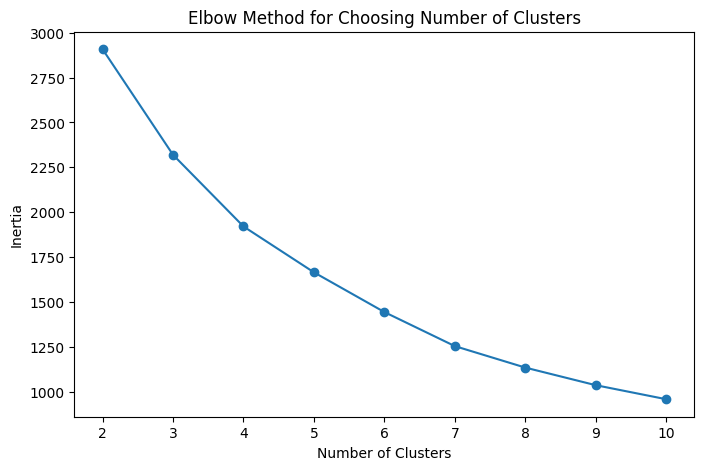

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Choosing Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')

plt.show()

In [14]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(
        "K =", k,
        "Silhouette Score =", round(score, 3)
    )

K = 2 Silhouette Score = 0.367
K = 3 Silhouette Score = 0.283
K = 4 Silhouette Score = 0.284
K = 5 Silhouette Score = 0.278
K = 6 Silhouette Score = 0.275
K = 7 Silhouette Score = 0.276
K = 8 Silhouette Score = 0.28
K = 9 Silhouette Score = 0.269
K = 10 Silhouette Score = 0.275


In [15]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = final_kmeans.fit_predict(X_scaled)

In [16]:
df['Cluster'].value_counts().sort_index()

Cluster
0    293
1    298
2    409
Name: count, dtype: int64

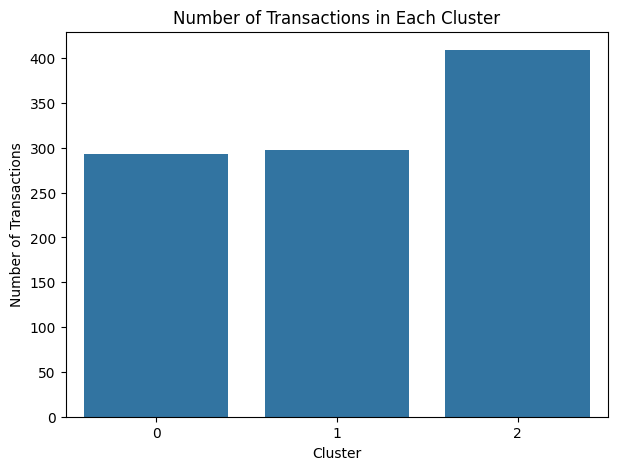

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Cluster'
)

plt.title('Number of Transactions in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Transactions')

plt.show()

In [18]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary

,Unit price,Quantity,Sales,gross income,Rating
Cluster,,,,,
0,31.890478,7.290102,241.762500,11.512500,7.180887
1,79.616342,7.802013,642.680547,30.603836,6.854027
2,55.262958,2.564792,148.194458,7.056879,6.910024


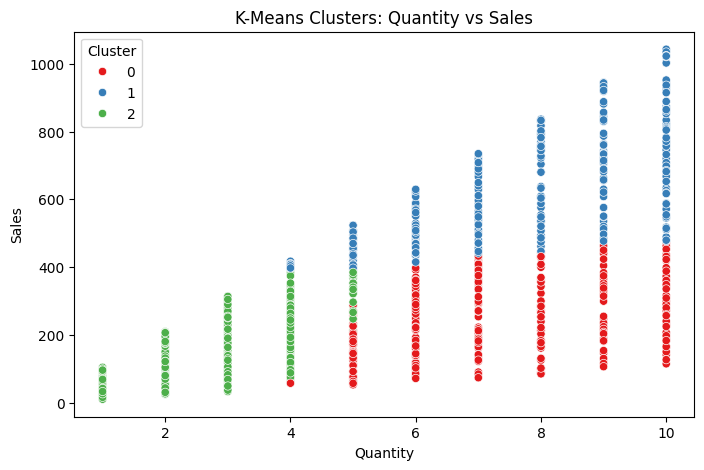

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Sales',
    hue='Cluster',
    palette='Set1'
)

plt.title('K-Means Clusters: Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')


plt.savefig('quantity_sales_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [22]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = df['Cluster']

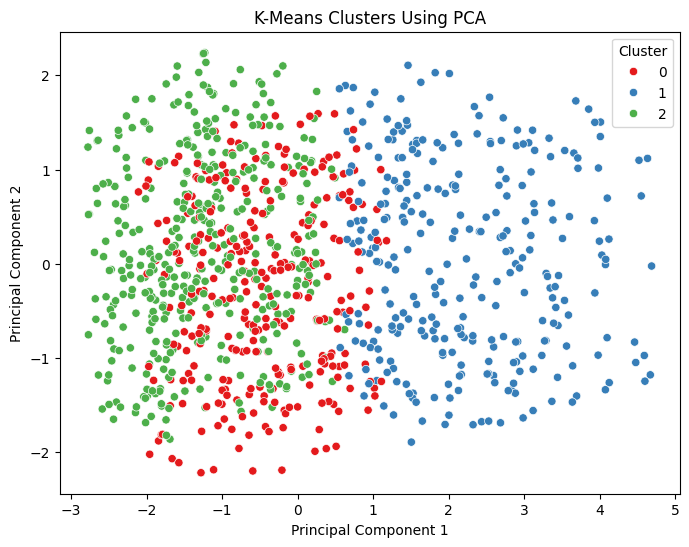

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title('K-Means Clusters Using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.savefig('pca_clusters.png', dpi=300, bbox_inches='tight')

plt.show()

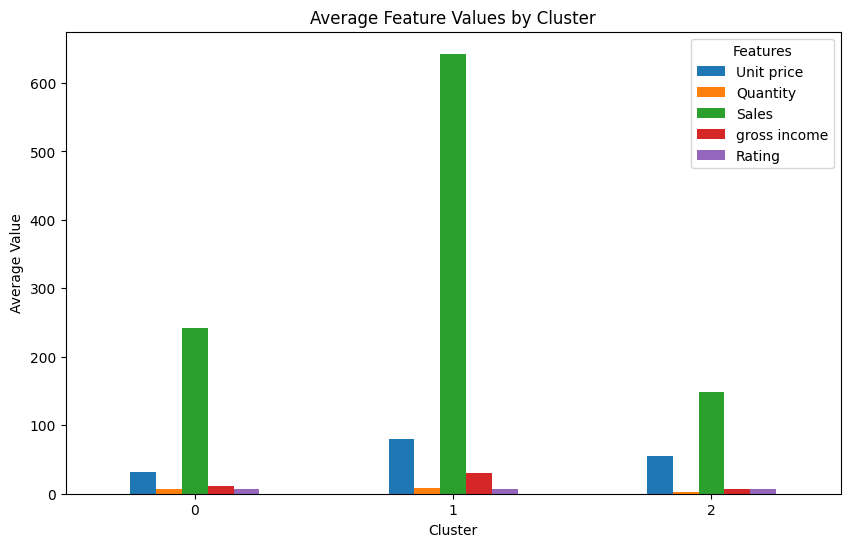

In [26]:
cluster_means = df.groupby('Cluster')[features].mean()

cluster_means.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Feature Values by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')

plt.xticks(rotation=0)
plt.legend(title='Features')

plt.savefig('cluster_comparison.png', dpi=300, bbox_inches='tight')

plt.show()